In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [35]:
df = pd.read_csv('data1C/final_data_1C.csv')
df.head()

,id,date,mood,activity,screen,call,sms,appCat.builtin,appCat.communication,appCat.entertainment,...,circumplex.valence_mean_3d_hist,mood_std_3d_hist,activity_std_3d_hist,screen_std_3d_hist,mood_change_today_vs_yesterday,activity_change_today_vs_yesterday,screen_change_today_vs_yesterday,day_of_week,is_weekend,mood_next_day
0,AS14.01,2014-03-23,6.80,0.142741,6773.832001,0.0,0.0,1286.246,5237.319,94.346,...,0.400000,0.000000,0.000000,0.000000,0.40,-0.094139,631.671002,6,1,6.00
1,AS14.01,2014-03-24,6.00,0.078961,15047.351001,10.0,0.0,866.956,9270.629,976.971,...,0.600000,0.282843,0.066566,446.658849,-0.80,-0.063780,8273.518999,0,0,6.75
2,AS14.01,2014-03-25,6.75,0.098374,15381.207999,0.0,1.0,1032.768,10276.751,68.206,...,0.400000,0.400000,0.079444,4969.113500,0.75,0.019413,333.856998,1,0,6.60
3,AS14.01,2014-03-26,6.60,0.101308,13585.707000,0.0,0.0,1167.497,8988.753,910.479,...,0.433333,0.448144,0.032694,4875.952876,-0.15,0.002934,-1795.500998,2,0,7.00
4,AS14.01,2014-03-27,7.00,0.159511,9360.814999,2.0,1.0,1229.327,6936.512,639.339,...,0.366667,0.396863,0.012144,954.959643,0.40,0.058202,-4224.892001,3,0,6.40


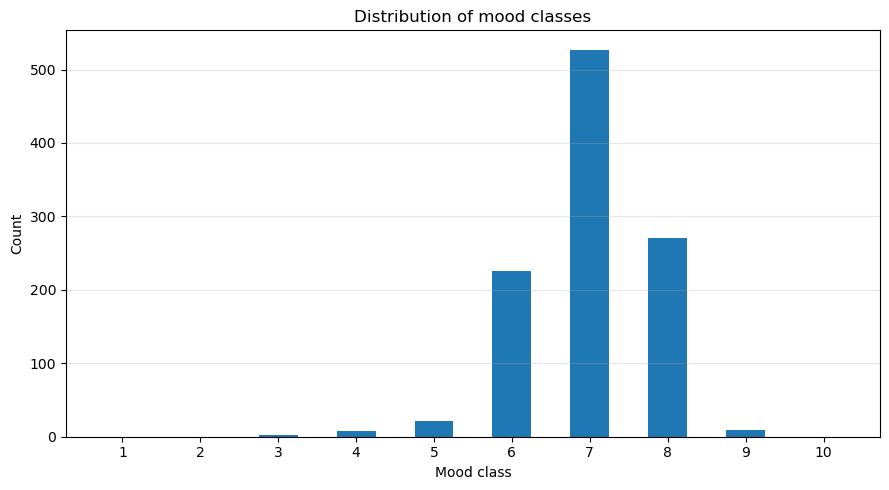

In [36]:
df["mood_class"] = df["mood"].round().clip(1, 10).astype(int)

counts = df["mood_class"].value_counts().sort_index().reindex(range(1, 11), fill_value=0)

plt.figure(figsize=(9, 5))
plt.bar(counts.index, counts.values, width=0.5)
plt.title("Distribution of mood classes")
plt.xlabel("Mood class")
plt.ylabel("Count")
plt.xticks(range(1, 11))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
x = df.drop(columns="mood_next_day")

low  = df["mood_next_day"].quantile(0.33)
high = df["mood_next_day"].quantile(0.67)

def mood_to_class(x):
    if x <= low:  return 0
    elif x <= high: return 1
    else: return 2
y = df["mood_next_day"].apply(mood_to_class)
y.value_counts()

mood_next_day
0    402
2    345
1    316
Name: count, dtype: int64

In [38]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(splitter.split(x, y, groups=df["id"]))

X_train, X_test = x.iloc[train_idx], x.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Verify no participant overlap
train_ids = df["id"].iloc[train_idx].unique()
test_ids  = df["id"].iloc[test_idx].unique()
print("Train participants:", len(train_ids))
print("Test participants:", len(test_ids))
print("Overlap:", set(train_ids) & set(test_ids))  

Train participants: 21
Test participants: 6
Overlap: set()


In [39]:
df["day_of_week"] = pd.to_datetime(df["date"]).dt.dayofweek
print(X_train.dtypes)

id                                        str
date                                      str
mood                                  float64
activity                              float64
screen                                float64
call                                  float64
sms                                   float64
appCat.builtin                        float64
appCat.communication                  float64
appCat.entertainment                  float64
appCat.finance                        float64
appCat.game                           float64
appCat.office                         float64
appCat.other                          float64
appCat.social                         float64
appCat.travel                         float64
appCat.unknown                        float64
appCat.utilities                      float64
appCat.weather                        float64
circumplex.arousal                    float64
circumplex.valence                    float64
mood_lag1                         

In [40]:
# Drop any non-numeric columns before fitting
cols_to_drop = X_train.select_dtypes(exclude="number").columns.tolist()
print("Dropping:", cols_to_drop)  # verify what gets dropped

X_train = X_train.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

Dropping: ['id', 'date']


In [ ]:
#scaling all features within the same range, done after splitting into train/test to avoid leaking test statistics into training
#class_weight=balanced penalizes misclassifying the minority classes more heavily, to make sure the SVM doesn´t just learn to predict the majority classes
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(class_weight="balanced"))])




# C : control tradeoff between smooth decision boundary and classifying training points correctly. low c = smoother, more generalizable, high c = fits training data more tightly
# kernel : how the svm maps data to higher dimensions, rbf assumes non-linear relationships, linear works with classes that are linearly separable
# gamma : controls how far the influence of a single training point reaches into the rbf kernel
param_grid = {
    "svm__C" : [0.1, 1, 10],
    "svm__kernel" : ["rbf", "linear"],
    "svm__gamma" : ["scale", "auto"]
}

#gridssearch to find best hyperparams, evaluates each combination using cross-validation. Using GroupKFold to make sure no participant appear in both the fold'set
#train and val set. 
#Using f1 score which is better for unbalanced datasets, computes f1 seperatly for each class and averages them equally. 
cv = GroupKFold(n_splits=5)
search = GridSearchCV(pipe, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
search.fit(X_train, y_train, groups=df["id"].iloc[train_idx])

print("Best CV f1_macro:", search.best_score_)
print("Best params:", search.best_params_)


Best CV f1_macro: 0.4411150376039483
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}


GridSearchCV automatically retrains the best model found on the full training set after finding the best parameters. 

              precision    recall  f1-score   support

         low       0.61      0.64      0.63        87
      medium       0.41      0.52      0.46        86
        high       0.33      0.19      0.24        68

    accuracy                           0.47       241
   macro avg       0.45      0.45      0.44       241
weighted avg       0.46      0.47      0.46       241



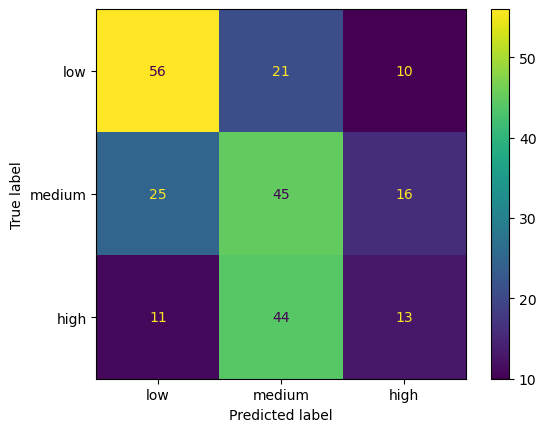

In [45]:
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["low", "medium", "high"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["low", "medium", "high"])
disp.plot()
